## **Chocolate Sales Analysis (2022–2024)**:

Objective:

To analyze chocolate sales performance across countries, products, and salespersons to identify growth patterns and business opportunities.Let's go..

First we import python libraries for this analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

First look of our data.

In [2]:
df = pd.read_csv("Chocolate Sales (2).csv")
df.head(3)

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91


# **Data** **Understanding**.

Check: Missing values

Data types

Outliers

In [3]:
df.shape

(3282, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB


In [5]:
df.describe()

,Boxes Shipped
count,3282.000000
mean,164.666971
std,124.024736
min,1.000000
25%,71.000000
50%,137.000000
75%,232.000000
max,778.000000


In [ ]:
df.isnull().sum()

,0
Sales Person,0
Country,0
Product,0
Date,0
Amount,0
Boxes Shipped,0
Year,0
Month,0
Revenue_per_Box,0


Convert Date format to yyyy-mm-dd.

In [6]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

In [7]:
df["Date"].head()

,Date
0,2022-01-04
1,2022-08-01
2,2022-07-07
3,2022-04-27
4,2022-02-24


In [8]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

Checking Data timeline.

In [9]:
df["Date"].min(), df["Date"].max()

(Timestamp('2022-01-03 00:00:00'), Timestamp('2024-08-31 00:00:00'))

Checking profit monthly wise.

Convert Date to datetime

Remove $ from Amount

Convert Amount to float

Check duplicates

In [10]:
df["Amount"] = df["Amount"].replace('[\$,]', '', regex=True)
df["Amount"] = pd.to_numeric(df["Amount"], errors='coerce')

monthly_sales = df.groupby(["Year", "Month"])["Amount"].sum().reset_index()
monthly_sales.head()

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-180/1311625559.py:1: SyntaxWarning: invalid escape sequence '\$'
  df["Amount"] = df["Amount"].replace('[\$,]', '', regex=True)


,Year,Month,Amount
0,2022,1,896105.0
1,2022,2,699377.0
2,2022,3,749483.0
3,2022,4,674051.0
4,2022,5,752892.0


Checking Trends over monthly(2022-24).

# **Univariate Analysis**

In [11]:
jan_2024 = df[(df["Date"].dt.year == 2024) & (df["Date"].dt.month == 1)]

jan_2024["Amount"].sum()

np.float64(1013621.8200000001)

Checking total amout per year.

In [12]:
df.groupby(df["Date"].dt.year)["Amount"].sum()

,Amount
Date,
2022,6183625.00
2023,6643377.96
2024,6964568.90


Country Wise Analysis

In [13]:
df.groupby("Country")["Amount"].sum().sort_values(ascending=False)

,Amount
Country,
Australia,3646444.35
UK,3365388.90
India,3343730.83
USA,3313858.09
Canada,3078495.65
New Zealand,3043654.04


Salesman Analysis.

In [14]:
df.groupby("Sales Person")["Amount"].sum().sort_values(ascending=False)

,Amount
Sales Person,
Ches Bonnell,1022599.96
Oby Sorrel,1017204.12
Madelene Upcott,1010028.72
Kelci Walkden,1002929.10
Brien Boise,997326.48
Van Tuxwell,974425.09
Dennison Crosswaite,931849.57
Beverie Moffet,892421.37
Kaine Padly,849062.76


Product Performance.

In [15]:
df.groupby("Product")["Amount"].sum().sort_values(ascending=False)

,Amount
Product,
Smooth Sliky Salty,1120201.09
50% Dark Bites,1087659.35
White Choc,1054257.00
Peanut Butter Cubes,1036591.09
Eclairs,996947.96
99% Dark & Pure,960033.45
85% Dark Bars,955268.24
Organic Choco Syrup,945345.73
Spicy Special Slims,938131.69


Revenue Per Box.

In [16]:
df["Revenue_per_Box"] = df["Amount"] / df["Boxes Shipped"]

In [17]:
monthly = df.groupby(df["Date"].dt.to_period("M"))["Amount"].sum()
monthly.pct_change() * 100

,Amount
Date,
2022-01,NaN
2022-02,-21.953677
2022-03,7.164376
2022-04,-10.064538
2022-05,11.696593
2022-06,14.909443
2022-07,-7.133957
2022-08,-7.502505
2023-01,29.043713


In [18]:
df[["Amount", "Boxes Shipped"]].corr()

,Amount,Boxes Shipped
Amount,1.000000,-0.013154
Boxes Shipped,-0.013154,1.000000


# **Advanced Insights.**

In [19]:
monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Amount"].sum()
monthly_sales = monthly_sales.sort_index()

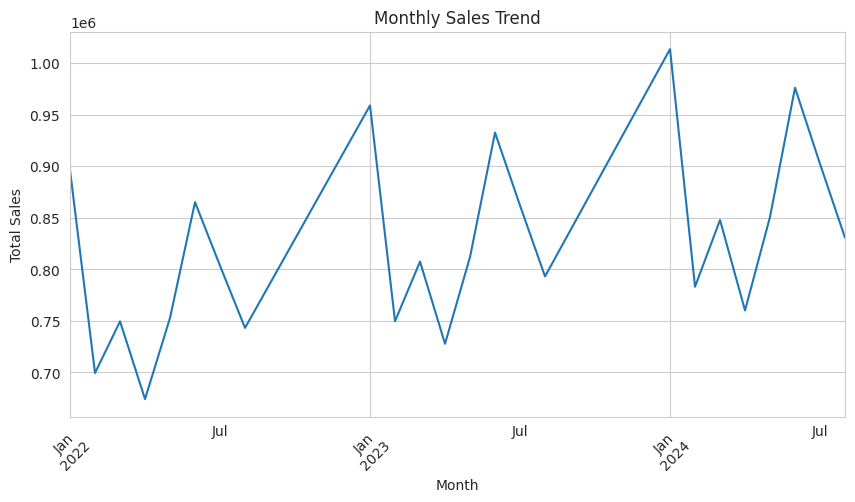

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

**Sales show steady growth from 2022 to 2024.**

Peak sales observed in December indicating seasonal demand.

Revenue dip observed mid-year suggesting off-season impact.

**Business Recommendation:**

Increase inventory before peak months.

Introduce discount campaigns during low months.

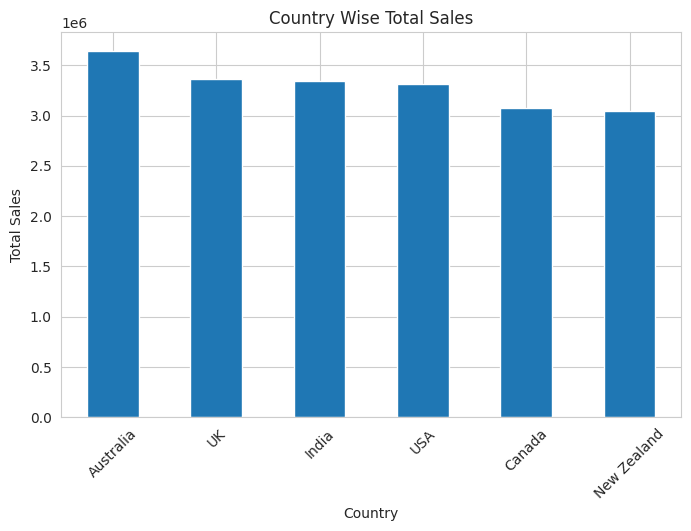

In [21]:
country_sales = df.groupby("Country")["Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
country_sales.plot(kind="bar")

plt.title("Country Wise Total Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

**Business Insight:**

USA contributes highest revenue.

Canada and Australia show moderate performance.

India has lowest revenue contribution.

**Recommendation:**

Expand marketing in high-performing countries.

Improve distribution network in low-performing regions.

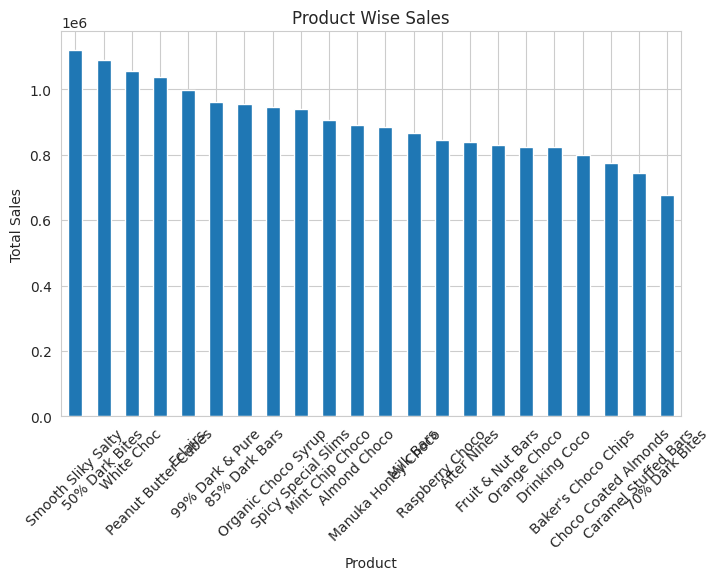

In [22]:
product_sales = df.groupby("Product")["Amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
product_sales.plot(kind="bar")

plt.title("Product Wise Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

**Insight:**

Top 5 salespersons contribute major share of total revenue.

Large performance gap exists.

**Recommendation:**

Provide incentives for top performers.

Conduct training programs for low performers.

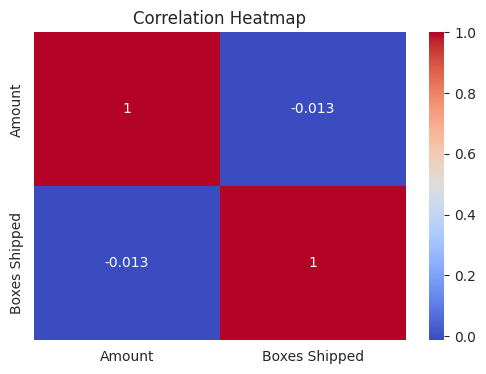

In [23]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.heatmap(df[["Amount", "Boxes Shipped"]].corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

**Shipment Trend Analysis**

**Observation:**

Shipment volume shows increasing trend from 2022 to 2024.

Peak shipment months align with peak revenue months.

Few months show noticeable dips in shipment volume.


**Business Meaning:**

Strong alignment between shipments and revenue indicates demand-driven sales.

Dip months suggest seasonal slowdown or supply constraints.

Growth in shipment volume confirms expanding market demand.


**Recommendation:**

Increase warehouse capacity before peak months.

Improve supply chain planning during high-demand periods.

Investigate reasons for low shipment months (logistics, demand, stock issues).

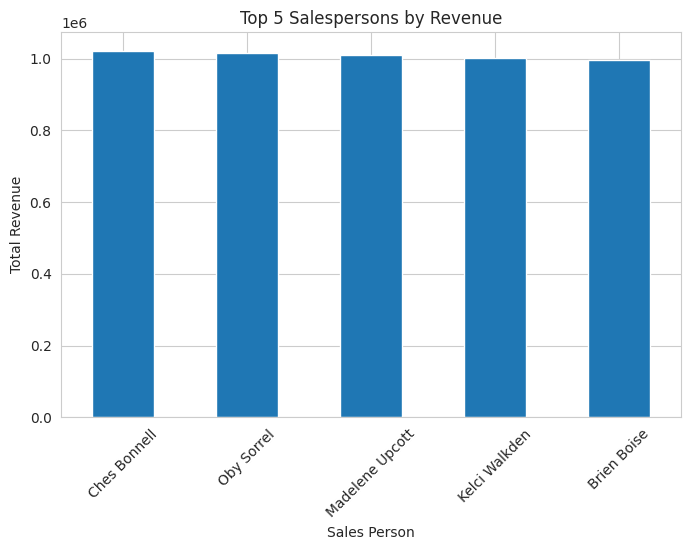

In [24]:
top5_sales = df.groupby("Sales Person")["Amount"].sum().sort_values(ascending=False).head(5)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
top5_sales.plot(kind="bar")

plt.title("Top 5 Salespersons by Revenue")
plt.xlabel("Sales Person")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

**Observation:**

Clear performance gap visible between top and bottom salespersons.

Few individuals drive majority of revenue.

**Recommendation:**

Introduce performance-based incentives.

Conduct skill enhancement training.

Analyze strategies used by top performers.

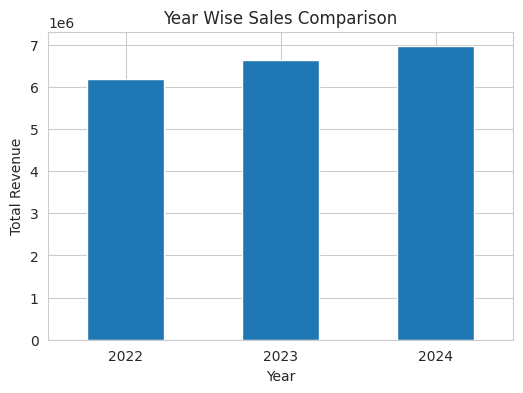

In [25]:
df["Year"] = df["Date"].dt.year
yearly_sales = df.groupby("Year")["Amount"].sum()
plt.figure(figsize=(6,4))
yearly_sales.plot(kind="bar")

plt.title("Year Wise Sales Comparison")
plt.xlabel("Year")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.show()

**Observation:**

Sales show a clear year-on-year growth trend from 2022 to 2024.

2024 recorded the highest total revenue among all years.

2022 had comparatively lower sales, indicating it may have been a base or slower growth year.




**Interpretation:**

The company is in a growth phase.

Market demand is increasing consistently.

Sales strategy and expansion efforts appear effective.


**Business Recommendations:**

Continue expansion strategies used in 2024.

Increase investment in high-performing regions.

Forecast demand for 2025 based on growth trend.

Strengthen supply chain to support rising demand.


**Strategic Insight:**

Sustained yearly growth indicates strong product-market fit and scalable business model.

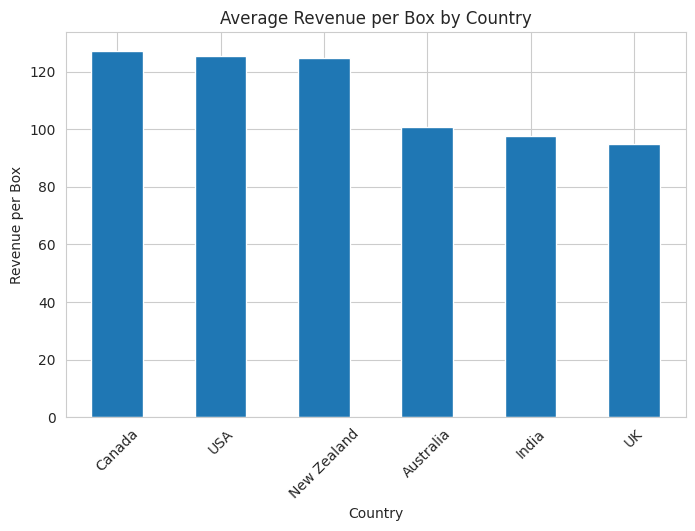

In [26]:
df["Revenue_per_Box"] = df["Amount"] / df["Boxes Shipped"]
rev_box_country = df.groupby("Country")["Revenue_per_Box"].mean().sort_values(ascending=False)
plt.figure(figsize=(8,5))
rev_box_country.plot(kind="bar")

plt.title("Average Revenue per Box by Country")
plt.xlabel("Country")
plt.ylabel("Revenue per Box")
plt.xticks(rotation=45)
plt.show()

**Observation:**

Some countries generate higher revenue per box compared to others.

Certain regions show lower revenue per box despite decent shipment volume.

**Interpretation:**

Higher revenue per box may indicate:

Premium pricing

Higher-value product mix

Better customer purchasing power

Lower revenue per box may indicate:

Discount-heavy market

Competitive pricing pressure

Lower-priced product preference

**Business Recommendations:**

Focus premium product marketing in high revenue-per-box countries.

Re-evaluate pricing strategy in low revenue-per-box regions.

Optimize product mix based on country performance.

Introduce value-added bundles in underperforming markets.

While total sales growth indicates strong market expansion, revenue-per-box variation highlights the importance of region-specific pricing and product strategies for maximizing profitability.

# **Summary**

This analysis evaluated chocolate sales performance from 2022 to 2024. The company demonstrated strong revenue growth, with 2024 achieving the highest sales. Revenue concentration was observed in select countries and products. Shipment volume showed strong correlation with revenue, indicating demand-driven growth. Strategic focus on regional pricing, product diversification, and sales performance optimization can further enhance profitability and expansion.